In [3]:

import numpy as np
import pandas as pd
%matplotlib inline

pd.options.display.float_format = '{:.2f}'.format
import openpyxl
import warnings
warnings.filterwarnings('ignore')


import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import lightgbm as lgb

from statsmodels.tsa.seasonal import MSTL
from sklearn.metrics import mean_absolute_error

### 1. Считываем данные и предобрабатываем

In [4]:
df = pd.read_excel('data/Тестовое задание DS.xlsx', sheet_name="TimeSeries")
calendar_df = pd.read_excel('data/Тестовое задание DS.xlsx', sheet_name="Calendar")


In [5]:

# переименуем колонки
df = df.rename(columns={
    "торговая точка": "store_id",
    "дата": "DATE",
    "продажи": "SALES_QUANTITY",
    "номер дня года": "day_of_year_ts"
})

calendar_df = calendar_df.rename(columns={
    "day_id": "DATE",
    "day_year": "day_of_year",
    "day_week": "day_week"
})

# типы
df["DATE"] = pd.to_datetime(df["DATE"])
calendar_df["DATE"] = pd.to_datetime(calendar_df["DATE"])

# сортировка
df = df.sort_values(["store_id", "DATE"]).reset_index(drop=True)
calendar_df = calendar_df.sort_values("DATE").reset_index(drop=True)

TRAIN_END = pd.Timestamp("2023-07-31")
FORECAST_END = pd.Timestamp("2023-12-31")

print(df.head())
print(df.columns.tolist())
print()
print(calendar_df.head())
print(calendar_df.columns.tolist())
print()
print("Количество точек:", df["store_id"].nunique())
print("Период истории:", df["DATE"].min(), "->", df["DATE"].max())

   store_id       DATE  SALES_QUANTITY  day_of_year_ts
0         1 2019-06-10               1             161
1         1 2019-06-11              14             162
2         1 2019-06-12             332             163
3         1 2019-06-13             770             164
4         1 2019-06-14             840             165
['store_id', 'DATE', 'SALES_QUANTITY', 'day_of_year_ts']

        DATE  week_id  month_id  year_id  day_of_year  day_week  day_number  \
0 2016-01-01   201553    201601     2016            1         5           1   
1 2016-01-02   201553    201601     2016            2         6           2   
2 2016-01-03   201553    201601     2016            3         7           3   
3 2016-01-04   201601    201601     2016            4         1           4   
4 2016-01-05   201601    201601     2016            5         2           5   

   week_number  month_number  quarter_number  is_holiday  is_warm  \
0           53             1               1           1        0   

### 2. Восстанавливаем полный таймлайн

In [6]:


def build_full_timeline(df: pd.DataFrame, forecast_end: pd.Timestamp) -> pd.DataFrame:
    """
    Для каждой точки:
    1) берем дату старта ряда
    2) строим полный ежедневный диапазон до конца прогноза
    3) мерджим фактические продажи
    """
    parts = []

    for store_id, g in df.groupby("store_id"):
        g = g.sort_values("DATE").copy()

        start_date = g["DATE"].min()
        last_fact_date = g["DATE"].max()

        full_dates = pd.date_range(start=start_date, end=forecast_end, freq="D")

        base = pd.DataFrame({
            "store_id": store_id,
            "DATE": full_dates
        })

        base = base.merge(
            g[["DATE", "SALES_QUANTITY"]],
            on="DATE",
            how="left"
        )

        # пропуск в историческом окне
        base["is_missing_original"] = (
            base["SALES_QUANTITY"].isna() &
            (base["DATE"] <= last_fact_date)
        ).astype("uint8")

        # будущее относительно train end
        base["is_future"] = (base["DATE"] > TRAIN_END).astype("uint8")

        parts.append(base)

    full_df = pd.concat(parts, ignore_index=True)
    full_df = full_df.sort_values(["store_id", "DATE"]).reset_index(drop=True)
    return full_df


full_df = build_full_timeline(df, FORECAST_END)

# мерджим календарь
full_df = full_df.merge(
    calendar_df,
    on="DATE",
    how="left"
)

# известные аномальные периоды из задания
anomaly_periods = pd.DataFrame({
    "start_date": pd.to_datetime([
        "2020-03-30",
        "2021-06-12",
        "2021-10-26"
    ]),
    "end_date": pd.to_datetime([
        "2020-07-31",
        "2021-07-31",
        "2021-11-12"
    ]),
    "comment": [
        "Всеобщий локдаун в связи с COVID-19",
        "Ограничение на посещения общественных мест в МСК (только по QR-кодам)",
        "Локдаун в МСК в связи с ростом заболеваний COVID-19"
    ]
})

full_df["is_known_anomaly"] = 0

for _, row in anomaly_periods.iterrows():
    mask = full_df["DATE"].between(row["start_date"], row["end_date"])
    full_df.loc[mask, "is_known_anomaly"] = 1

print(full_df.head(20))
print()
print(full_df[["store_id", "DATE", "SALES_QUANTITY", "is_missing_original", "is_future", "is_known_anomaly"]].head(20))

    store_id       DATE  SALES_QUANTITY  is_missing_original  is_future  \
0          1 2019-06-10            1.00                    0          0   
1          1 2019-06-11           14.00                    0          0   
2          1 2019-06-12          332.00                    0          0   
3          1 2019-06-13          770.00                    0          0   
4          1 2019-06-14          840.00                    0          0   
5          1 2019-06-15          947.00                    0          0   
6          1 2019-06-16         1115.00                    0          0   
7          1 2019-06-17          908.00                    0          0   
8          1 2019-06-18          927.00                    0          0   
9          1 2019-06-19          992.00                    0          0   
10         1 2019-06-20         1066.00                    0          0   
11         1 2019-06-21         1078.00                    0          0   
12         1 2019-06-22  

In [7]:
store_example = full_df["store_id"].iloc[0]
full_df[full_df["store_id"] == store_example].head(20)

,store_id,DATE,SALES_QUANTITY,is_missing_original,is_future,week_id,month_id,year_id,day_of_year,day_week,day_number,week_number,month_number,quarter_number,is_holiday,is_warm,is_black_friday,is_known_anomaly
0,1,2019-06-10,1.00,0,0,201924,201906,2019,161,1,10,24,6,2,0,1,0,0
1,1,2019-06-11,14.00,0,0,201924,201906,2019,162,2,11,24,6,2,0,1,0,0
2,1,2019-06-12,332.00,0,0,201924,201906,2019,163,3,12,24,6,2,1,1,0,0
3,1,2019-06-13,770.00,0,0,201924,201906,2019,164,4,13,24,6,2,0,1,0,0
4,1,2019-06-14,840.00,0,0,201924,201906,2019,165,5,14,24,6,2,0,1,0,0
5,1,2019-06-15,947.00,0,0,201924,201906,2019,166,6,15,24,6,2,0,1,0,0
6,1,2019-06-16,1115.00,0,0,201924,201906,2019,167,7,16,24,6,2,0,1,0,0
7,1,2019-06-17,908.00,0,0,201925,201906,2019,168,1,17,25,6,2,0,1,0,0
8,1,2019-06-18,927.00,0,0,201925,201906,2019,169,2,18,25,6,2,0,1,0,0
9,1,2019-06-19,992.00,0,0,201925,201906,2019,170,3,19,25,6,2,0,1,0,0


### 3. ОЧИСТКА РЯДА + MSTL

In [8]:

def clean_series_one_store_no_leak(g: pd.DataFrame, train_end: pd.Timestamp) -> pd.DataFrame:
    """
    Очистка ряда без даталика:
    - используем только прошлые значения
    - без center=True
    - без двусторонней интерполяции
    """
    g = g.sort_values("DATE").copy()

    hist_mask = g["DATE"] <= train_end
    hist = g.loc[hist_mask, ["DATE", "SALES_QUANTITY", "is_missing_original", "is_known_anomaly"]].copy()
    hist = hist.set_index("DATE")

    y = hist["SALES_QUANTITY"].copy()

    # 1) только forward-fill как временная заглушка, без подглядывания вперед
    y_ffill = y.ffill()

    # если в самом начале есть NaN, можно добить глобальной стартовой медианой ряда
    start_fill_value = y.median()
    y_ffill = y_ffill.fillna(start_fill_value)

    # 2) только прошлое окно: shift(1) + rolling(...)
    past_median = (
        y_ffill.shift(1)
              .rolling(window=21, min_periods=7)
              .median()
    )

    abs_dev = (y_ffill - past_median).abs()

    past_mad = (
        abs_dev.shift(1)
               .rolling(window=21, min_periods=7)
               .median()
    )

    robust_sigma = 1.4826 * past_mad

    is_outlier = (abs_dev > 3 * robust_sigma).fillna(False)

    replace_mask = (
        hist["is_missing_original"].astype(bool) |
        hist["is_known_anomaly"].astype(bool) |
        is_outlier
    )

    y_clean = y.copy()

    # заменяем только на past_median
    y_clean[replace_mask] = past_median[replace_mask]

    # если после этого остались NaN, опять только ffill
    y_clean = y_clean.ffill().fillna(start_fill_value).clip(lower=0)

    hist["sales_clean"] = y_clean
    hist["is_outlier"] = is_outlier.astype("uint8")
    hist["is_replaced"] = replace_mask.astype("uint8")

    g = g.merge(
        hist[["sales_clean", "is_outlier", "is_replaced"]],
        left_on="DATE",
        right_index=True,
        how="left"
    )

    return g


full_df = (
    full_df.groupby("store_id", group_keys=False)
           .apply(lambda g: clean_series_one_store_no_leak(g, TRAIN_END))
           .reset_index(drop=True)
)

full_df["target_clean"] = full_df["sales_clean"]

full_df

,store_id,DATE,SALES_QUANTITY,is_missing_original,is_future,week_id,month_id,year_id,day_of_year,day_week,...,month_number,quarter_number,is_holiday,is_warm,is_black_friday,is_known_anomaly,sales_clean,is_outlier,is_replaced,target_clean
0,1,2019-06-10,1.00,0,0,201924,201906,2019,161,1,...,6,2,0,1,0,0,1.00,0.00,0.00,1.00
1,1,2019-06-11,14.00,0,0,201924,201906,2019,162,2,...,6,2,0,1,0,0,14.00,0.00,0.00,14.00
2,1,2019-06-12,332.00,0,0,201924,201906,2019,163,3,...,6,2,1,1,0,0,332.00,0.00,0.00,332.00
3,1,2019-06-13,770.00,0,0,201924,201906,2019,164,4,...,6,2,0,1,0,0,770.00,0.00,0.00,770.00
4,1,2019-06-14,840.00,0,0,201924,201906,2019,165,5,...,6,2,0,1,0,0,840.00,0.00,0.00,840.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10948,5,2023-12-27,NaN,0,1,202352,202312,2023,361,3,...,12,4,0,0,0,0,NaN,NaN,NaN,NaN
10949,5,2023-12-28,NaN,0,1,202352,202312,2023,362,4,...,12,4,0,0,0,0,NaN,NaN,NaN,NaN
10950,5,2023-12-29,NaN,0,1,202352,202312,2023,363,5,...,12,4,0,0,0,0,NaN,NaN,NaN,NaN
10951,5,2023-12-30,NaN,0,1,202352,202312,2023,364,6,...,12,4,0,0,0,0,NaN,NaN,NaN,NaN


In [9]:
# =========================
# 3A. MSTL-ДЕКОМПОЗИЦИЯ
# =========================

from statsmodels.tsa.seasonal import MSTL

def decompose_store_mstl(full_df: pd.DataFrame,
                         store_id,
                         train_end: pd.Timestamp):
    """
    Декомпозиция очищенного ряда магазина на:
    - trend
    - weekly seasonality
    - yearly seasonality
    - residual

    Важно:
    используем только исторический период до train_end.
    """
    g = full_df[full_df["store_id"] == store_id].copy()
    g = g[g["DATE"] <= train_end].copy()

    s = (
        g[["DATE", "sales_clean"]]
        .dropna()
        .set_index("DATE")["sales_clean"]
        .asfreq("D")
    )

    # если истории мало, годовую сезонность лучше не насиловать
    if len(s) >= 730:
        periods = [7, 365]
    elif len(s) >= 60:
        periods = [7]
    else:
        raise ValueError(f"Слишком короткая история для store_id={store_id}")

    res = MSTL(
        s,
        periods=periods,
        stl_kwargs={"robust": True}
    ).fit()

    return s, res

In [10]:
# =========================
# 3B. ГРАФИКИ КОМПОНЕНТ MSTL
# =========================

def plot_mstl_components(full_df: pd.DataFrame,
                         store_id,
                         train_end: pd.Timestamp):
    """
    Рисуем:
    1. очищенный ряд
    2. trend
    3. seasonal_7
    4. seasonal_365 (если есть)
    5. residual
    """
    s, res = decompose_store_mstl(full_df, store_id, train_end)

    seasonal = res.seasonal
    if isinstance(seasonal, pd.Series):
        seasonal = seasonal.to_frame("seasonal_7")

    nrows = 2 + seasonal.shape[1] + 1
    fig, axes = plt.subplots(nrows, 1, figsize=(16, 3 * nrows), sharex=True)

    # 1. сам очищенный ряд
    axes[0].plot(s.index, s.values)
    axes[0].set_title(f"Store {store_id}: cleaned series")
    axes[0].grid(True)

    # 2. тренд
    axes[1].plot(res.trend.index, res.trend.values)
    axes[1].set_title("Trend")
    axes[1].grid(True)

    # 3..N сезонности
    for i, col in enumerate(seasonal.columns, start=2):
        axes[i].plot(seasonal.index, seasonal[col].values)
        axes[i].set_title(col)
        axes[i].grid(True)

    # Residual
    axes[-1].plot(res.resid.index, res.resid.values)
    axes[-1].set_title("Residual")
    axes[-1].grid(True)

    plt.tight_layout()
    plt.show()

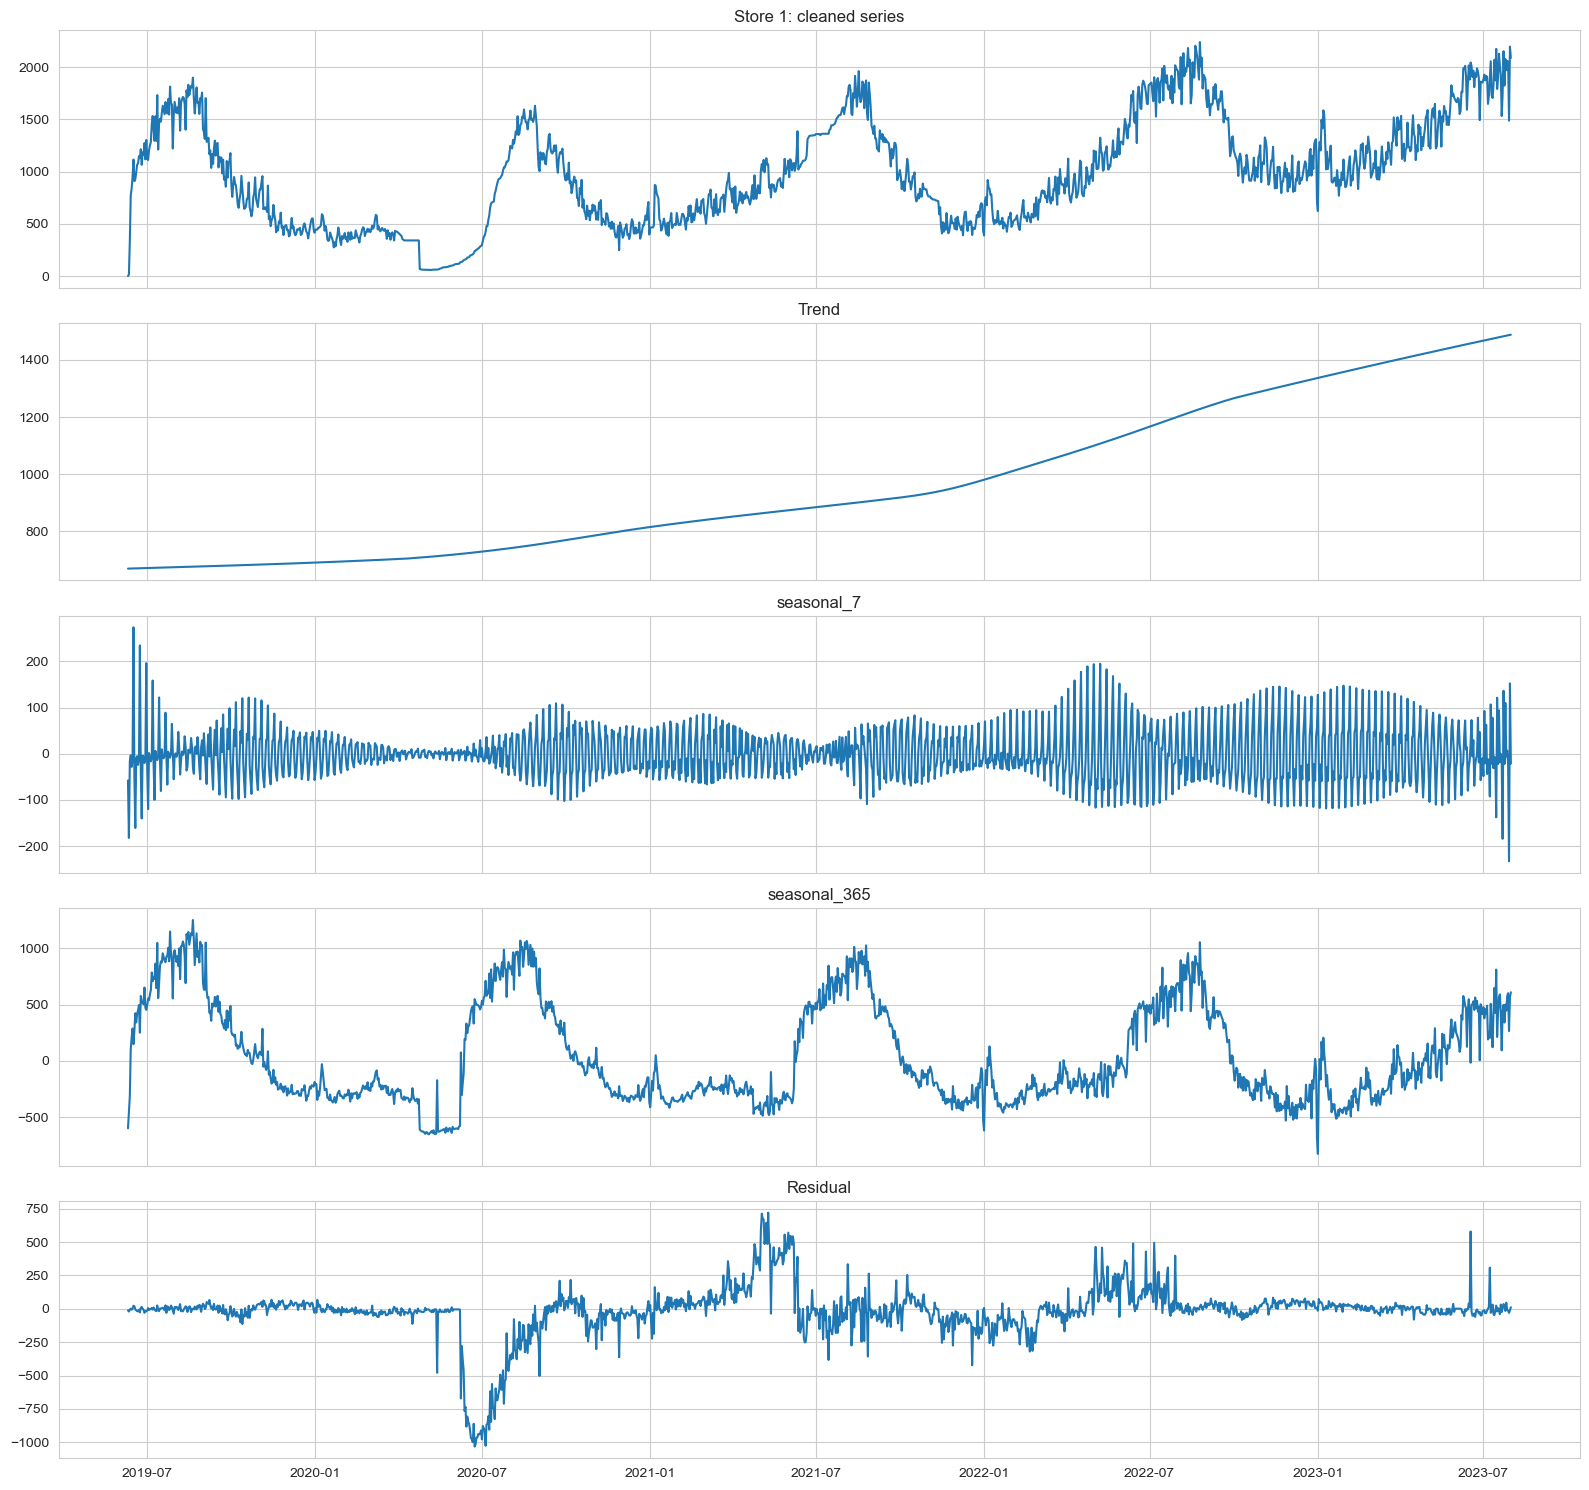

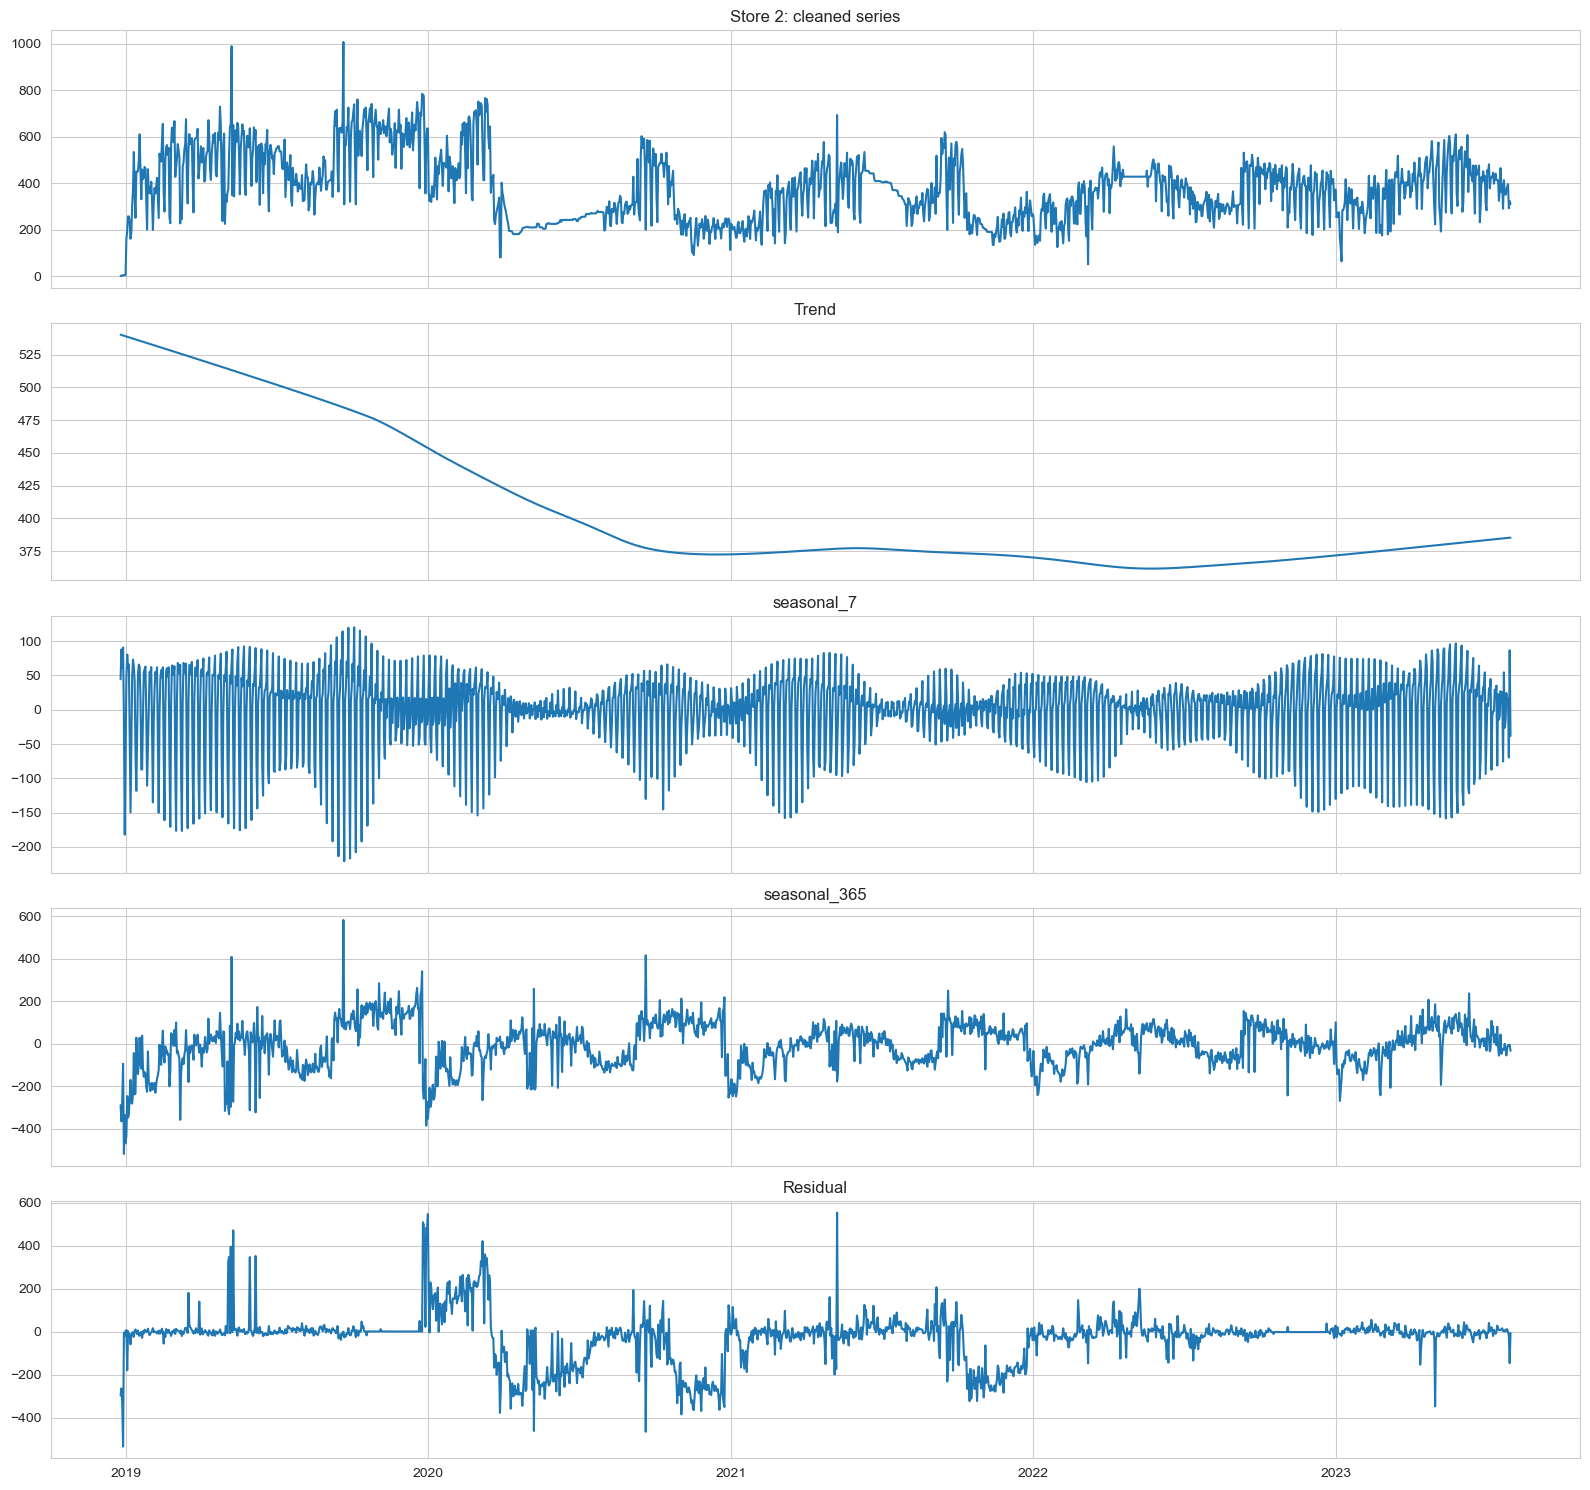

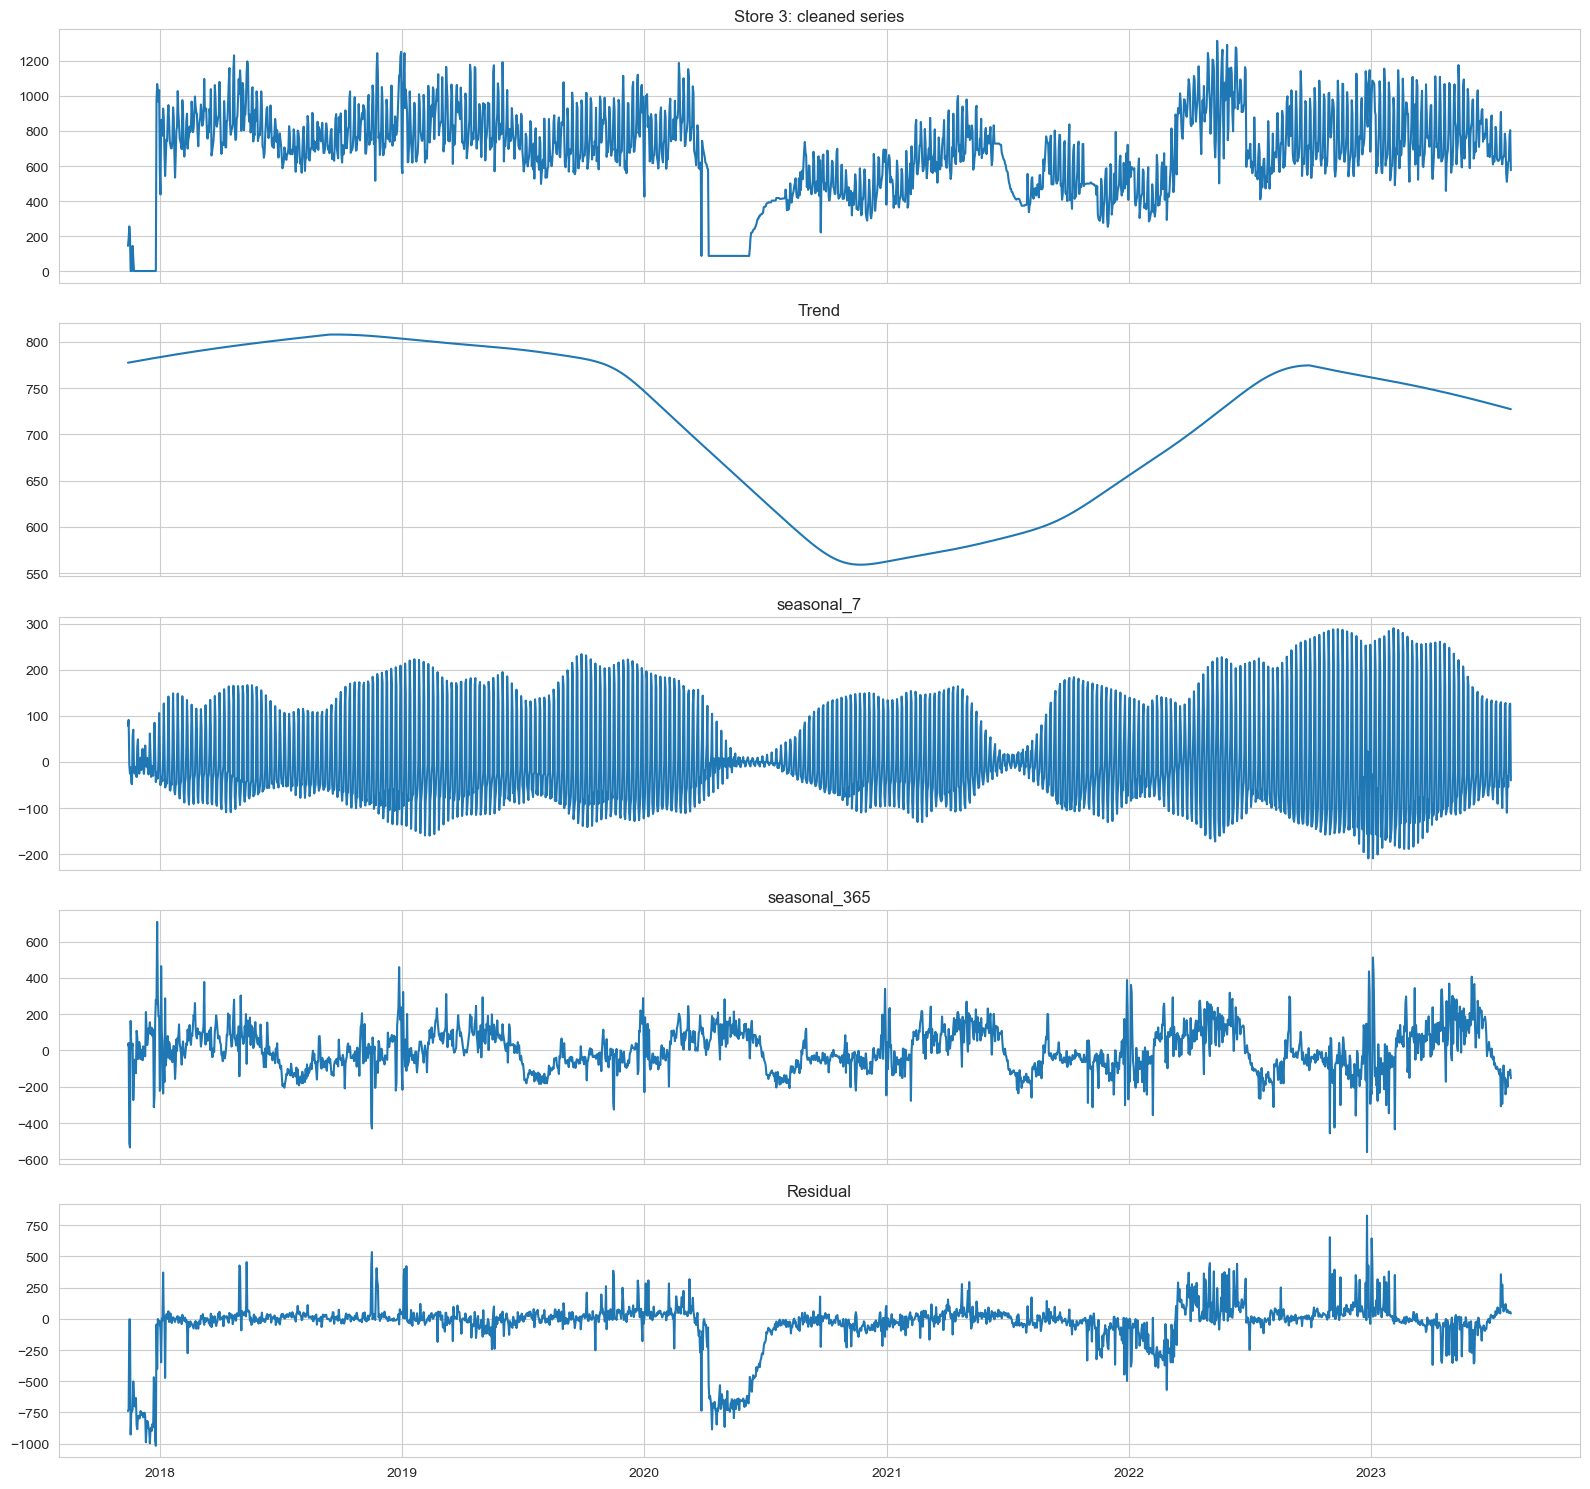

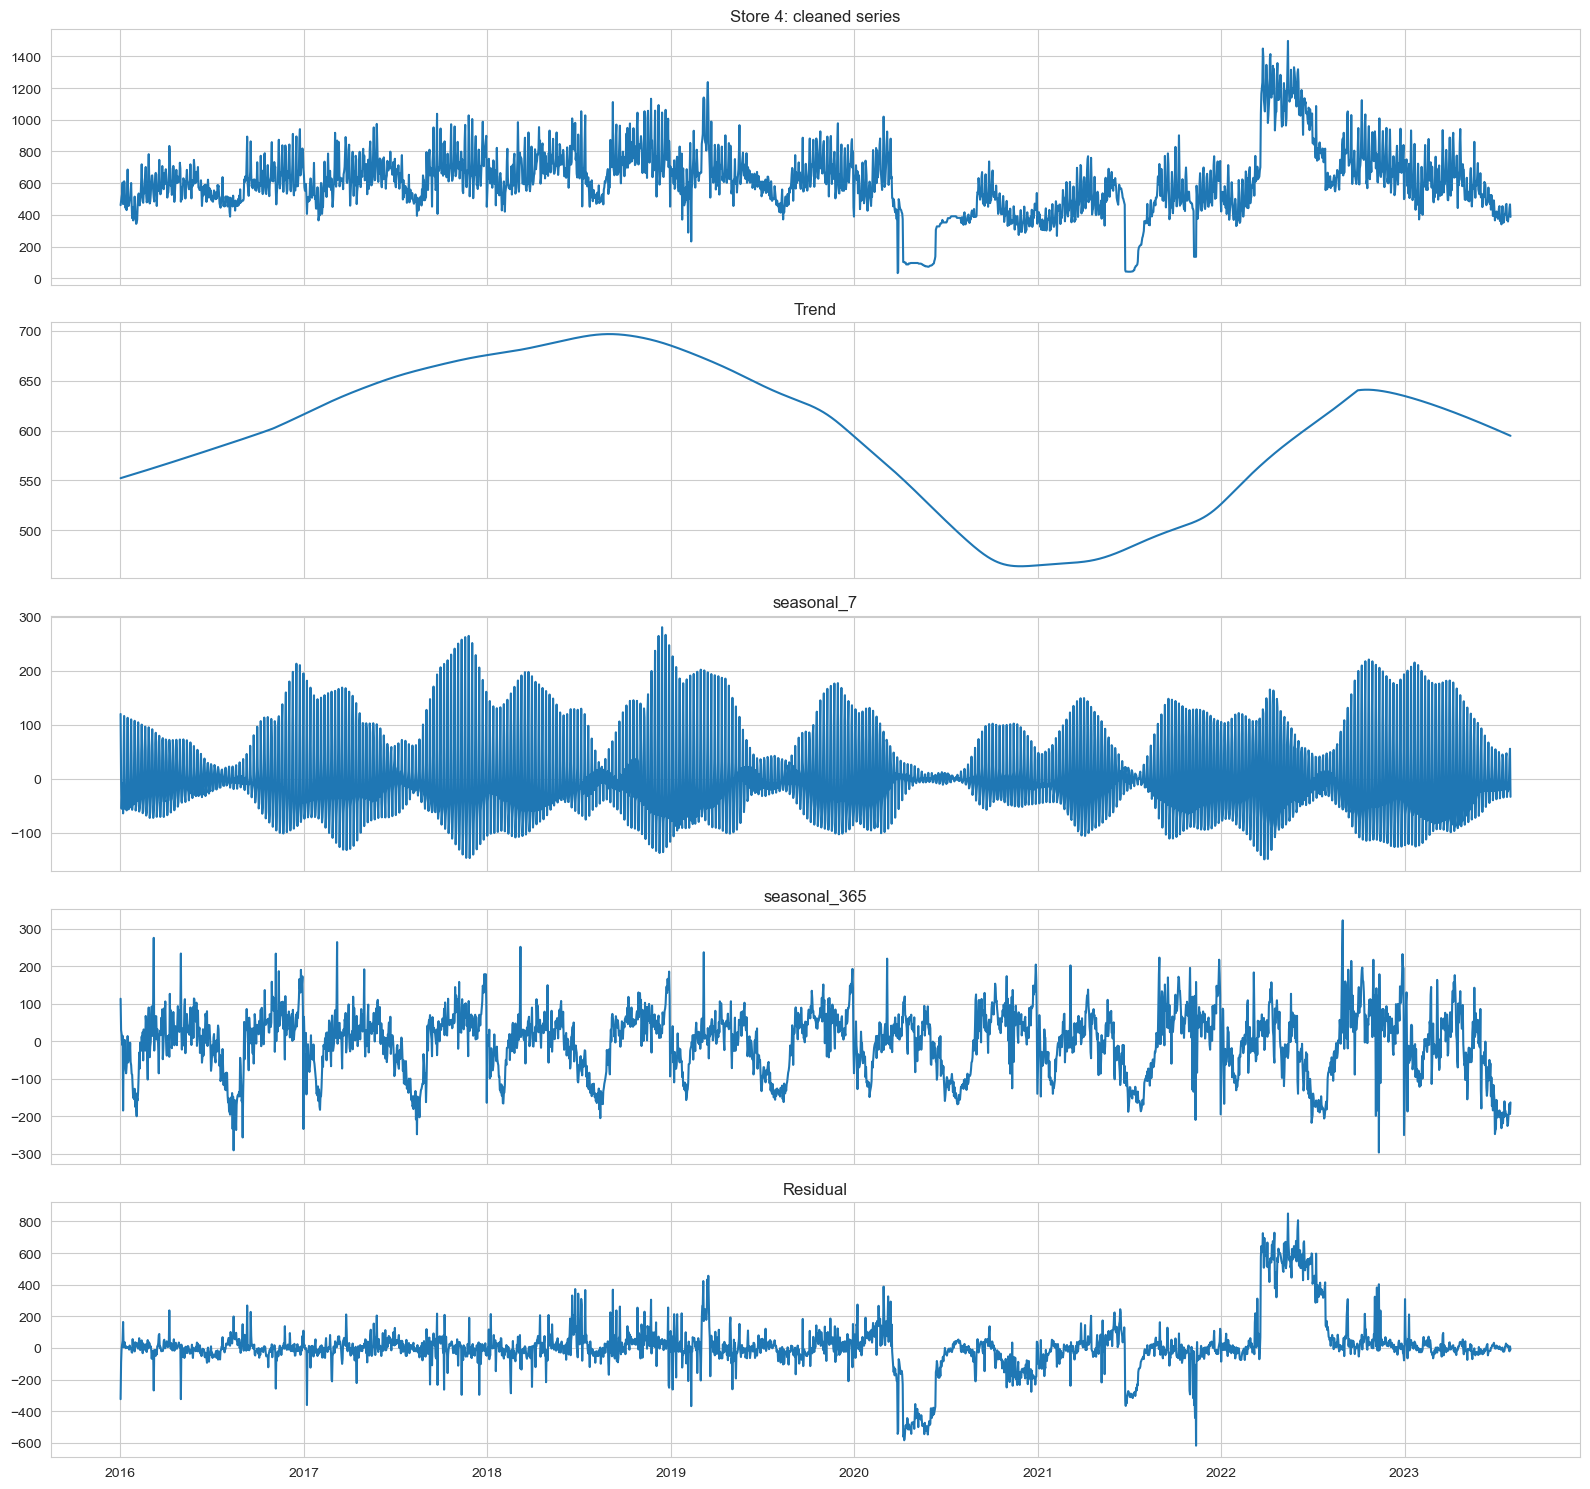

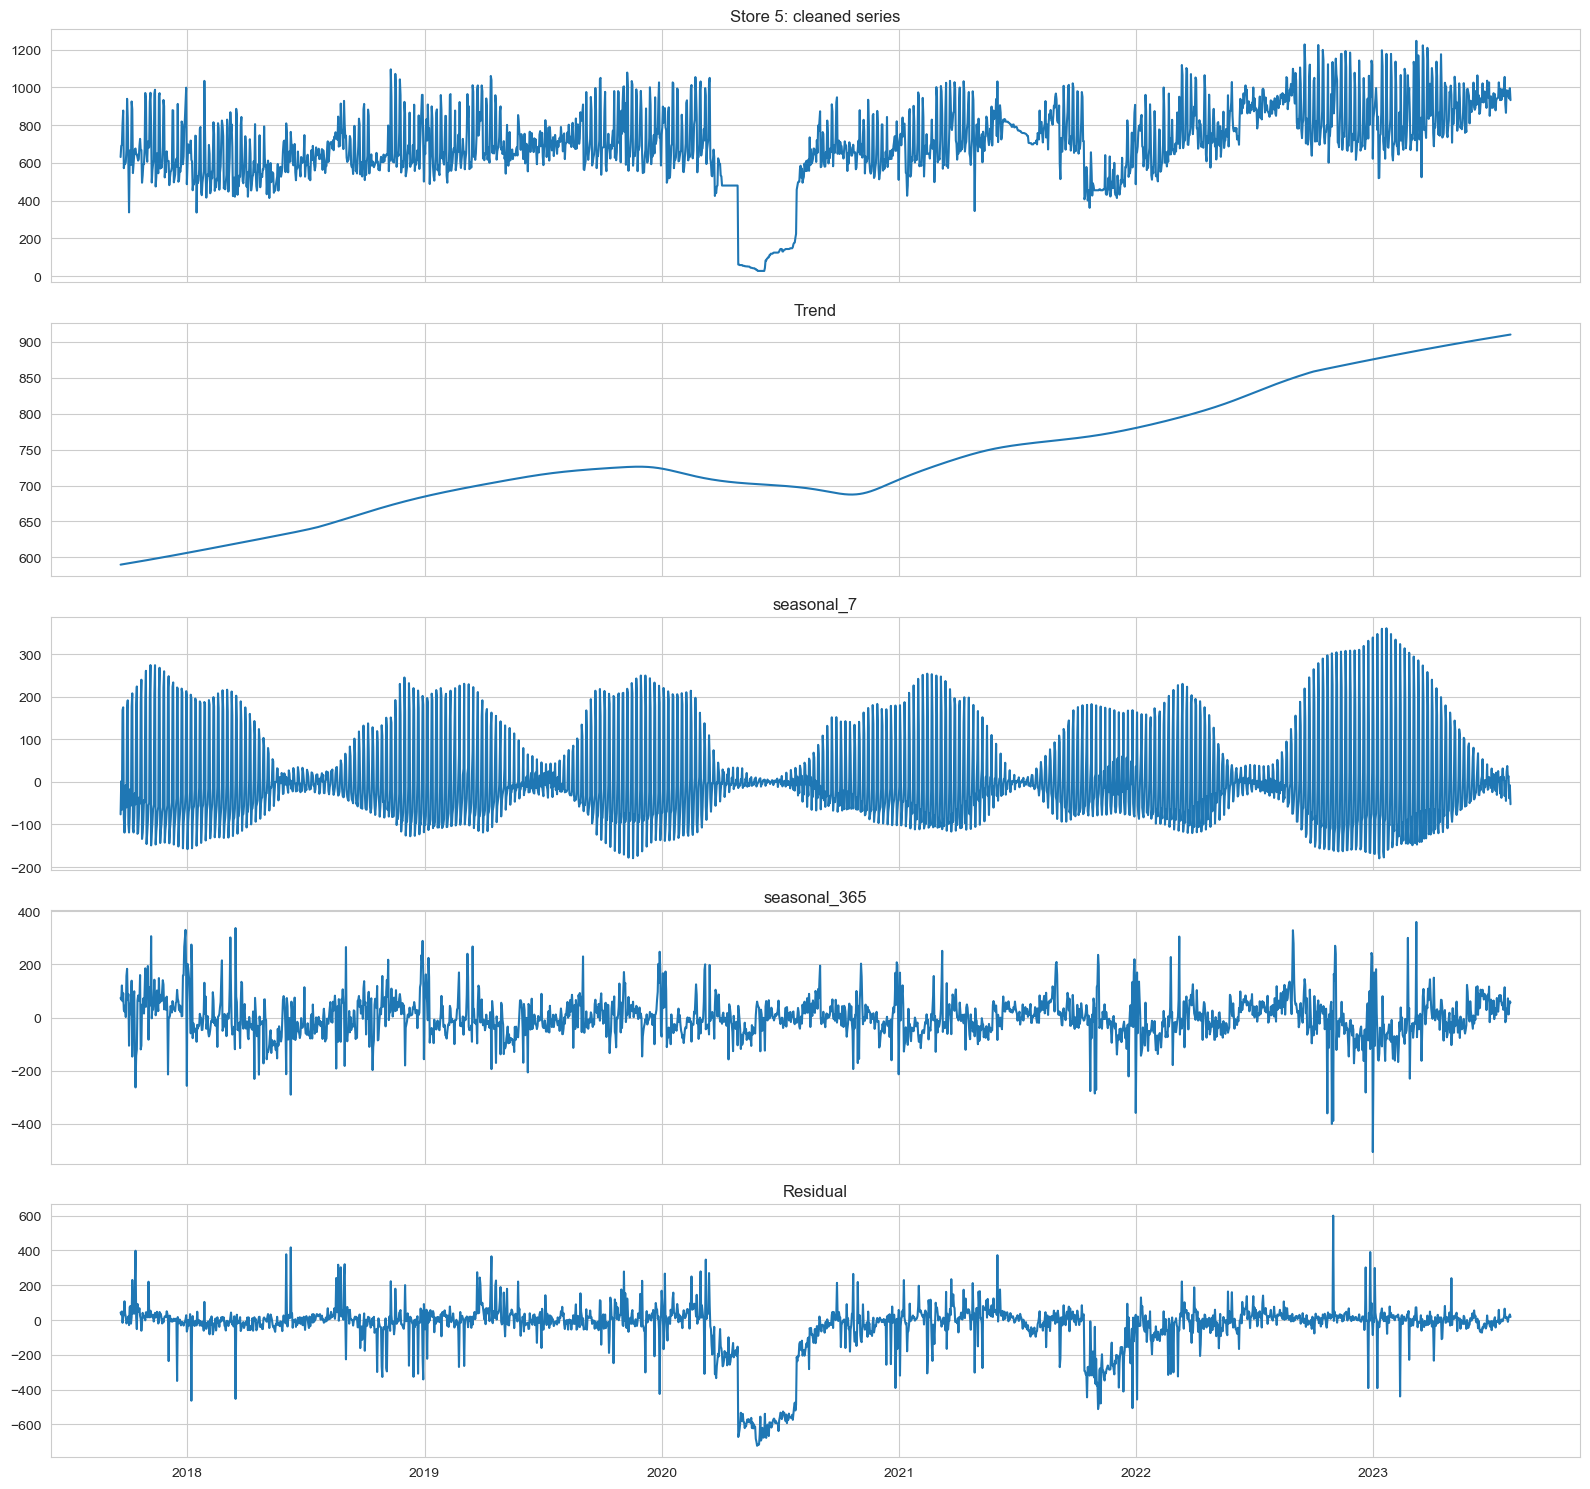

In [11]:
for store_id in sorted(full_df["store_id"].unique()):
    plot_mstl_components(full_df, store_id, TRAIN_END)

##### вывод по графикам разложения
Декомпозиция показала, что для всех магазинов наиболее устойчивой и интерпретируемой компонентой является недельная сезонность.
Для части магазинов также прослеживается долгосрочный восходящий или нисходящий тренд, а для некоторых — смена режима со спадом и последующим восстановлением.
Годовая сезонность присутствует, но выражена менее стабильно и на отдельных рядах зашумлена структурными сдвигами и аномальными периодами.
Остаточные компоненты подтверждают наличие внешних шоков и разовых событий, не объясняемых только трендом и сезонностью.

### 4. Создаем фичи

In [12]:


def create_date_features(data_to_process: pd.DataFrame) -> pd.DataFrame:
    """
    Создание признаков, связанных с датой
    """
    data = data_to_process.copy()

    data["DATE"] = pd.to_datetime(data["DATE"])
    data["month"] = data["DATE"].dt.month.astype("uint16")
    data["year"] = data["DATE"].dt.year.astype("uint16")
    data["quarter"] = data["DATE"].dt.quarter.astype("uint16")
    data["week_number_local"] = data["DATE"].dt.isocalendar().week.astype("uint16")
    data["day_of_week"] = data["DATE"].dt.dayofweek.astype("uint16")
    data["day_of_month"] = data["DATE"].dt.day.astype("uint16")
    data["is_weekend"] = (data["day_of_week"] >= 5).astype("uint16")

    # "сезон" как грубый категориальный признак
    data["season"] = np.where(data["month"].isin([12, 1, 2]), 0, 1).astype("uint16")
    data["season"] = np.where(data["month"].isin([6, 7, 8]), 2, data["season"]).astype("uint16")
    data["season"] = np.where(data["month"].isin([9, 10, 11]), 3, data["season"]).astype("uint16")

    # код магазина
    data["store_code"] = data["store_id"].astype("category").cat.codes.astype("int16")

    # порядковый день внутри ряда точки
    data["days_from_start"] = data.groupby("store_id").cumcount().astype("int32")

    return data


def create_lag_features(data_to_process: pd.DataFrame, n_shift: int, target: str) -> pd.DataFrame:
    """
    Создание lag признаков
    """
    data = data_to_process.copy().sort_values(by=["store_id", "DATE"]).reset_index(drop=True)

    lags = [1, 2, 3, 7, 14, 21, 28, 35, 56]
    for lag in lags:
        data[f"sales_lag_{lag}"] = data.groupby("store_id")[target].shift(n_shift + lag - 1)

    return data


def create_rolling_features(data_to_process: pd.DataFrame, n_shift: int, target: str) -> pd.DataFrame:
    """
    Создание rolling признаков
    """
    data = data_to_process.copy().sort_values(by=["store_id", "DATE"]).reset_index(drop=True)

    arr_window = [7, 14, 28, 56]

    shifted = data.groupby("store_id")[target].shift(n_shift)

    for i in arr_window:
        data[f"sales_roll_mean_{i}"] = (
            shifted.groupby(data["store_id"])
                   .rolling(i, min_periods=3)
                   .mean()
                   .reset_index(level=0, drop=True)
                   .round(2)
                   .astype("float32")
        )
        data[f"sales_roll_med_{i}"] = (
            shifted.groupby(data["store_id"])
                   .rolling(i, min_periods=3)
                   .median()
                   .reset_index(level=0, drop=True)
                   .round(2)
                   .astype("float32")
        )
        data[f"sales_roll_max_{i}"] = (
            shifted.groupby(data["store_id"])
                   .rolling(i, min_periods=3)
                   .max()
                   .reset_index(level=0, drop=True)
                   .round(2)
                   .astype("float32")
        )
        data[f"sales_roll_min_{i}"] = (
            shifted.groupby(data["store_id"])
                   .rolling(i, min_periods=3)
                   .min()
                   .reset_index(level=0, drop=True)
                   .round(2)
                   .astype("float32")
        )
        data[f"sales_roll_std_{i}"] = (
            shifted.groupby(data["store_id"])
                   .rolling(i, min_periods=3)
                   .std()
                   .reset_index(level=0, drop=True)
                   .round(2)
                   .astype("float32")
        )

    return data


def create_diff_features(data_to_process: pd.DataFrame) -> pd.DataFrame:
    """
    Создание diff / ratio признаков
    """
    df1 = data_to_process.copy()

    def safe_div(a, b):
        x = a / b
        x = x.replace([np.inf, -np.inf], np.nan)
        return x

    df1["sales_lag_3_mean"] = df1[["sales_lag_1", "sales_lag_2", "sales_lag_3"]].mean(axis=1)
    df1["sales_lag_7_mean"] = df1[["sales_lag_1", "sales_lag_2", "sales_lag_3", "sales_lag_7"]].mean(axis=1)

    df1["sales_roll_med_mean"] = df1[[
        "sales_roll_med_7",
        "sales_roll_med_14",
        "sales_roll_med_28",
        "sales_roll_med_56"
    ]].mean(axis=1)

    df1["sales_lag_grad_1_2"] = safe_div(df1["sales_lag_1"], df1["sales_lag_2"])
    df1["sales_lag_grad_1_7"] = safe_div(df1["sales_lag_1"], df1["sales_lag_7"])
    df1["sales_lag_grad_7_14"] = safe_div(df1["sales_lag_7"], df1["sales_lag_14"])
    df1["sales_lag_grad_1_28"] = safe_div(df1["sales_lag_1"], df1["sales_lag_28"])

    df1["sales_lag_grad_med_7"] = safe_div(df1["sales_lag_1"], df1["sales_roll_med_7"])
    df1["sales_lag_grad_mean_7"] = safe_div(df1["sales_lag_1"], df1["sales_roll_mean_7"])
    df1["sales_lag_grad_med_28"] = safe_div(df1["sales_lag_1"], df1["sales_roll_med_28"])
    df1["sales_lag_grad_mean_28"] = safe_div(df1["sales_lag_1"], df1["sales_roll_mean_28"])

    df1["diff_sales_mean1_7"] = df1["sales_lag_1"] - df1["sales_roll_mean_7"]
    df1["diff_sales_mean1_14"] = df1["sales_lag_1"] - df1["sales_roll_mean_14"]
    df1["diff_sales_mean1_28"] = df1["sales_lag_1"] - df1["sales_roll_mean_28"]

    df1["diff_sales_med1_7"] = df1["sales_lag_1"] - df1["sales_roll_med_7"]
    df1["diff_sales_med1_14"] = df1["sales_lag_1"] - df1["sales_roll_med_14"]
    df1["diff_sales_med1_28"] = df1["sales_lag_1"] - df1["sales_roll_med_28"]

    df1["diff_roll_mean_7_28"] = df1["sales_roll_mean_7"] - df1["sales_roll_mean_28"]
    df1["diff_roll_mean_14_56"] = df1["sales_roll_mean_14"] - df1["sales_roll_mean_56"]

    df1["relat_diff_roll_mean_7_28"] = safe_div(df1["diff_roll_mean_7_28"], df1["sales_roll_mean_28"])
    df1["relat_diff_roll_mean_14_56"] = safe_div(df1["diff_roll_mean_14_56"], df1["sales_roll_mean_56"])

    return df1


def generate_features(data_to_process: pd.DataFrame, shift_help: int, target: str) -> pd.DataFrame:
    """
    Генерация фичей
    """
    df1 = data_to_process.copy()
    df1 = create_date_features(df1)
    df1 = create_lag_features(df1, shift_help, target)
    df1 = create_rolling_features(df1, shift_help, target)
    df1 = create_diff_features(df1)

    return df1


feature_df = generate_features(full_df, shift_help=1, target="target_clean")

print(feature_df.head())
print()
print("shape:", feature_df.shape)

   store_id       DATE  SALES_QUANTITY  is_missing_original  is_future  \
0         1 2019-06-10            1.00                    0          0   
1         1 2019-06-11           14.00                    0          0   
2         1 2019-06-12          332.00                    0          0   
3         1 2019-06-13          770.00                    0          0   
4         1 2019-06-14          840.00                    0          0   

   week_id  month_id  year_id  day_of_year  day_week  ...  diff_sales_mean1_7  \
0   201924    201906     2019          161         1  ...                 NaN   
1   201924    201906     2019          162         2  ...                 NaN   
2   201924    201906     2019          163         3  ...                 NaN   
3   201924    201906     2019          164         4  ...              216.33   
4   201924    201906     2019          165         5  ...              490.75   

   diff_sales_mean1_14  diff_sales_mean1_28  diff_sales_med1_7  \
0 

### 5. Тестируем на даталик фичи

In [13]:
def test_feature_leaks(data_to_process: pd.DataFrame,
                       test_date: str,
                       target_col: str = "target_clean") -> None:
    """
    Проверка, что признаки до test_date не используют значения из test_date и позже.
    """
    sentinel = -99999999

    test_df = data_to_process.copy()
    test_date = pd.to_datetime(test_date)

    # все будущие значения таргета "ломаем"
    test_df.loc[test_df["DATE"] >= test_date, target_col] = sentinel

    # пересчитываем признаки
    feat_df = generate_features(test_df, shift_help=1, target=target_col)

    # берем только прошлое - там не должно быть sentinel в признаках
    check_df = feat_df[feat_df["DATE"] < test_date].copy()

    leak_cols = []

    for col in check_df.columns:
        if col.startswith("sales_") or col.startswith("diff_") or col.startswith("relat_"):
            col_min = check_df[col].min(skipna=True)
            if pd.notna(col_min) and col_min < -1000:
                leak_cols.append(col)

    if len(leak_cols) == 0:
        print("ЛИКА В ФИЧАХ НЕТ")
    else:
        print("ЛИК ОБНАРУЖЕН В ФИЧАХ:")
        for col in leak_cols:
            print(col)

test_feature_leaks(full_df, test_date="2023-06-01", target_col="target_clean")

ЛИКА В ФИЧАХ НЕТ


### 6. Обучаем модель

In [14]:


# берем только историю для обучения
train_df = feature_df[feature_df["DATE"] <= TRAIN_END].copy()

# список признаков
feature_cols = [
    "store_code",
    "days_from_start",
    "month",
    "year",
    "quarter",
    "week_number_local",
    "day_of_week",
    "day_of_month",
    "is_weekend",
    "season",
    "day_of_year",
    "day_week",
    "week_number",
    "month_number",
    "quarter_number",
    "is_holiday",
    "is_warm",
    "is_black_friday",
    "is_known_anomaly",
    "is_missing_original",

    "sales_lag_1",
    "sales_lag_2",
    "sales_lag_3",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_21",
    "sales_lag_28",
    "sales_lag_35",
    "sales_lag_56",

    "sales_roll_mean_7",
    "sales_roll_mean_14",
    "sales_roll_mean_28",
    "sales_roll_mean_56",

    "sales_roll_med_7",
    "sales_roll_med_14",
    "sales_roll_med_28",
    "sales_roll_med_56",

    "sales_roll_max_7",
    "sales_roll_max_14",
    "sales_roll_max_28",
    "sales_roll_max_56",

    "sales_roll_min_7",
    "sales_roll_min_14",
    "sales_roll_min_28",
    "sales_roll_min_56",

    "sales_roll_std_7",
    "sales_roll_std_14",
    "sales_roll_std_28",
    "sales_roll_std_56",

    "sales_lag_3_mean",
    "sales_lag_7_mean",
    "sales_roll_med_mean",

    "sales_lag_grad_1_2",
    "sales_lag_grad_1_7",
    "sales_lag_grad_7_14",
    "sales_lag_grad_1_28",

    "sales_lag_grad_med_7",
    "sales_lag_grad_mean_7",
    "sales_lag_grad_med_28",
    "sales_lag_grad_mean_28",

    "diff_sales_mean1_7",
    "diff_sales_mean1_14",
    "diff_sales_mean1_28",

    "diff_sales_med1_7",
    "diff_sales_med1_14",
    "diff_sales_med1_28",

    "diff_roll_mean_7_28",
    "diff_roll_mean_14_56",

    "relat_diff_roll_mean_7_28",
    "relat_diff_roll_mean_14_56",
]

# выбрасываем строки, где еще не хватает лагов / роллингов
train_df = train_df.dropna(subset=feature_cols + ["target_clean"]).copy()

# валидация: последние 60 дней истории
VAL_DAYS = 60
val_start = TRAIN_END - pd.Timedelta(days=VAL_DAYS - 1)

X_train = train_df.loc[train_df["DATE"] < val_start, feature_cols]
y_train = train_df.loc[train_df["DATE"] < val_start, "target_clean"]

X_valid = train_df.loc[train_df["DATE"] >= val_start, feature_cols]
y_valid = train_df.loc[train_df["DATE"] >= val_start, "target_clean"]

print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)

model = lgb.LGBMRegressor(

    objective="regression_l1",           # целевая: регрессия по абсолютной ошибке (MAE)
    n_estimators=2000,                # число деревьев (итераций бустинга)
    learning_rate=0.15,                  # скорость обучения (шаг градиента)
    max_depth=16,                        # макс. глубина дерева (контроль переобучения)
    lambda_l1=0.15,                      # L1-регуляризация (сжатие коэффициентов)
    lambda_l2=0.15,                      # L2-регуляризация (гладкость модели)
    min_gain_to_split=0.1,               # минимальный прирост для разбиения (min split gain)
    feature_fraction=0.8,                # доля фич, используемых при построении каждого дерева
    bagging_freq=5,                      # частота бутстрэп-подвыборки (0 — отключено)
    bagging_fraction=0.8,                # доля данных для бутстрэп-подвыборки
    path_smooth=0.1,                     # сглаживание пути предсказаний (уменьшение переобучения)
    boost_from_average=True,             # начинать бустинг с среднего таргета (ускоряет сход.)
    random_state=42,                     # seed для воспроизводимости
    feature_fraction_seed=42,            # seed для случайного отбора фич
    verbosity=-1,                        # уровень логирования (-1 или 0 — тише)

)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

valid_pred = model.predict(X_valid, num_iteration=model.best_iteration_)
mae = mean_absolute_error(y_valid, valid_pred)
print("Validation MAE:", mae)

Train shape: (9608, 70)
Valid shape: (300, 70)
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 61.5454
[200]	valid_0's l1: 61.1154
Early stopping, best iteration is:
[148]	valid_0's l1: 60.6925
Validation MAE: 60.692537828166536


### 7. Смотрим метрики на тестовом периоде

In [15]:
def calculate_metrics_by_store(result: pd.DataFrame,
                               true_sales: str,
                               pred_sales: str,
                               store_col: str = "store_id",
                               date_col: str = "DATE") -> pd.DataFrame:
    """
    Считает метрики по каждому магазину отдельно.
    Возвращает DataFrame со строкой на магазин + итоговую строку Total.
    """

    all_metrics = []

    for store_id in sorted(result[store_col].dropna().unique()):
        store_res = result[result[store_col] == store_id].copy()

        actual = store_res[true_sales].astype(float)
        predicted = store_res[pred_sales].astype(float)

        non_zero_mask = actual != 0

        wape = (
            100 * np.abs(actual - predicted).sum() / np.abs(actual).sum()
            if np.abs(actual).sum() != 0 else np.nan
        )

        mape = (
            100 * np.mean(np.abs((actual[non_zero_mask] - predicted[non_zero_mask]) / actual[non_zero_mask]))
            if non_zero_mask.sum() > 0 else np.nan
        )

        mae = np.mean(np.abs(actual - predicted))
        rmse = np.sqrt(np.mean((actual - predicted) ** 2))

        mean_actual = np.mean(actual)
        mean_predicted = np.mean(predicted)

        std_actual = np.std(actual)
        std_predicted = np.std(predicted)

        bias = np.mean(predicted - actual)

        denom = np.sum((actual - np.mean(actual)) ** 2)
        r2 = 1 - (np.sum((actual - predicted) ** 2) / denom) if denom != 0 else np.nan

        days_cnt = store_res[date_col].nunique()

        all_metrics.append([
            store_id,
            wape,
            mape,
            mae,
            rmse,
            mean_actual,
            mean_predicted,
            std_actual,
            std_predicted,
            bias,
            r2,
            days_cnt
        ])

    metrics_df = pd.DataFrame(all_metrics, columns=[
        "store_id",
        "WAPE_%",
        "MAPE_%",
        "MAE",
        "RMSE",
        "Mean_Actual",
        "Mean_Predicted",
        "Std_Actual",
        "Std_Predicted",
        "Bias",
        "R2",
        "days_cnt"
    ])

    # итоговая строка по всем магазинам
    total_actual = result[true_sales].astype(float)
    total_predicted = result[pred_sales].astype(float)
    total_non_zero_mask = total_actual != 0

    total_row = pd.DataFrame({
        "store_id": ["Total"],
        "WAPE_%": [
            100 * np.abs(total_actual - total_predicted).sum() / np.abs(total_actual).sum()
            if np.abs(total_actual).sum() != 0 else np.nan
        ],
        "MAPE_%": [
            100 * np.mean(np.abs((total_actual[total_non_zero_mask] - total_predicted[total_non_zero_mask]) /
                                 total_actual[total_non_zero_mask]))
            if total_non_zero_mask.sum() > 0 else np.nan
        ],
        "MAE": [np.mean(np.abs(total_actual - total_predicted))],
        "RMSE": [np.sqrt(np.mean((total_actual - total_predicted) ** 2))],
        "Mean_Actual": [np.mean(total_actual)],
        "Mean_Predicted": [np.mean(total_predicted)],
        "Std_Actual": [np.std(total_actual)],
        "Std_Predicted": [np.std(total_predicted)],
        "Bias": [np.mean(total_predicted - total_actual)],
        "R2": [
            1 - (np.sum((total_actual - total_predicted) ** 2) /
                 np.sum((total_actual - np.mean(total_actual)) ** 2))
            if np.sum((total_actual - np.mean(total_actual)) ** 2) != 0 else np.nan
        ],
        "days_cnt": [result[date_col].nunique()]
    })

    metrics_df = pd.concat([metrics_df, total_row], ignore_index=True)

    return metrics_df

In [16]:
valid_result = train_df.loc[
    train_df["DATE"] >= val_start,
    ["store_id", "DATE", "target_clean"]
].copy()

valid_result["prediction"] = valid_pred

metrics_by_store = calculate_metrics_by_store(
    result=valid_result,
    true_sales="target_clean",
    pred_sales="prediction",
    store_col="store_id",
    date_col="DATE"
)

metrics_by_store

,store_id,WAPE_%,MAPE_%,MAE,RMSE,Mean_Actual,Mean_Predicted,Std_Actual,Std_Predicted,Bias,R2,days_cnt
0,1,6.83,6.94,128.20,165.56,1875.85,1838.17,169.20,67.05,-37.68,0.04,60
1,2,11.78,12.76,48.03,62.17,407.60,411.22,74.36,71.62,3.62,0.30,60
2,3,6.69,6.75,49.50,59.11,740.35,755.07,119.29,114.73,14.72,0.75,60
3,4,8.09,8.06,36.20,48.83,447.28,456.29,64.74,71.96,9.01,0.43,60
4,5,4.39,4.41,41.54,54.38,945.57,946.08,48.06,39.04,0.52,-0.28,60
5,Total,6.87,7.78,60.69,89.57,883.33,881.37,544.20,522.84,-1.96,0.97,60


На валидации длиной 60 дней модель показала суммарный WAPE 6.87% по 5 магазинам.
По отдельным магазинам WAPE находится в диапазоне от 4.39% до 11.78%.
Наиболее сложным оказался магазин 2, а наиболее качественные результаты получены по магазинам 3 и 5.

### 8. Обучаем модель на всем доступном временном ряду


In [17]:
best_n_estimators = model.best_iteration_ if model.best_iteration_ is not None else 1500

final_model = lgb.LGBMRegressor(
     objective="regression_l1",
    n_estimators=2000,
    learning_rate=0.15,
    max_depth=16,
    lambda_l1=0.15,
    lambda_l2=0.15,
    min_gain_to_split=0.1,
    feature_fraction=0.8,
    bagging_freq=5,
    bagging_fraction=0.8,
    path_smooth=0.1,
    boost_from_average=True,
    random_state=42,
    feature_fraction_seed=42,
    verbosity=-1
)

final_model.fit(train_df[feature_cols], train_df["target_clean"])

LGBMRegressor(bagging_fraction=0.8, bagging_freq=5, boost_from_average=True,
              feature_fraction=0.8, feature_fraction_seed=42, lambda_l1=0.15,
              lambda_l2=0.15, learning_rate=0.15, max_depth=16,
              min_gain_to_split=0.1, n_estimators=2000,
              objective='regression_l1', path_smooth=0.1, random_state=42,
              verbosity=-1)

### 9. Прогноз


In [18]:
def recursive_forecast(full_df: pd.DataFrame,
                       model,
                       feature_cols: list,
                       train_end: pd.Timestamp,
                       forecast_end: pd.Timestamp) -> pd.DataFrame:
    """
    Идем по одному дню вперед:
    1) на текущую дату считаем признаки
    2) предсказываем target_clean
    3) записываем прогноз назад в ряд
    4) следующая дата уже использует этот прогноз как лаг
    """
    result_df = full_df.copy()

    # в будущем не должно быть реальных target_clean
    result_df.loc[result_df["DATE"] > train_end, "target_clean"] = np.nan

    current_date = train_end + pd.Timedelta(days=1)

    while current_date <= forecast_end:
        temp = generate_features(result_df.copy(), shift_help=1, target="target_clean")

        mask = temp["DATE"] == current_date
        X_next = temp.loc[mask, feature_cols].copy()

        pred = model.predict(X_next)
        pred = np.clip(pred, a_min=0, a_max=None)

        result_df.loc[result_df["DATE"] == current_date, "target_clean"] = pred

        current_date += pd.Timedelta(days=1)

    return result_df

forecast_df = recursive_forecast(
    full_df=full_df,
    model=final_model,
    feature_cols=feature_cols,
    train_end=TRAIN_END,
    forecast_end=FORECAST_END
)

forecast_df["forecast"] = np.where(
    forecast_df["DATE"] > TRAIN_END,
    forecast_df["target_clean"],
    np.nan
)

forecast_result = forecast_df.loc[
    forecast_df["DATE"] > TRAIN_END,
    ["store_id", "DATE", "forecast"]
].copy()

forecast_result.head(20)

,store_id,DATE,forecast
1513,1,2023-08-01,1945.00
1514,1,2023-08-02,2008.35
1515,1,2023-08-03,1990.78
1516,1,2023-08-04,2012.39
1517,1,2023-08-05,2040.54
1518,1,2023-08-06,1924.89
1519,1,2023-08-07,1840.48
1520,1,2023-08-08,1873.08
1521,1,2023-08-09,1888.36
1522,1,2023-08-10,1873.73


In [21]:
forecast_result

,store_id,DATE,forecast
1513,1,2023-08-01,1945.00
1514,1,2023-08-02,2008.35
1515,1,2023-08-03,1990.78
1516,1,2023-08-04,2012.39
1517,1,2023-08-05,2040.54
...,...,...,...
10948,5,2023-12-27,1207.33
10949,5,2023-12-28,1214.02
10950,5,2023-12-29,1213.92
10951,5,2023-12-30,1188.14


### 10. Строим графики


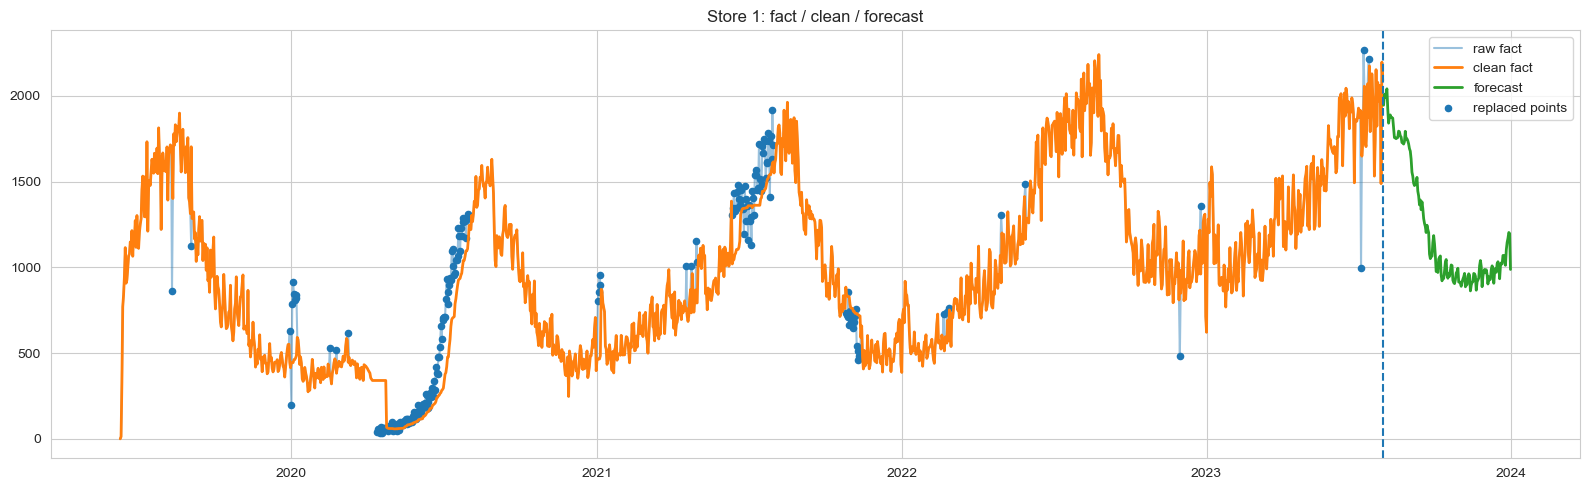

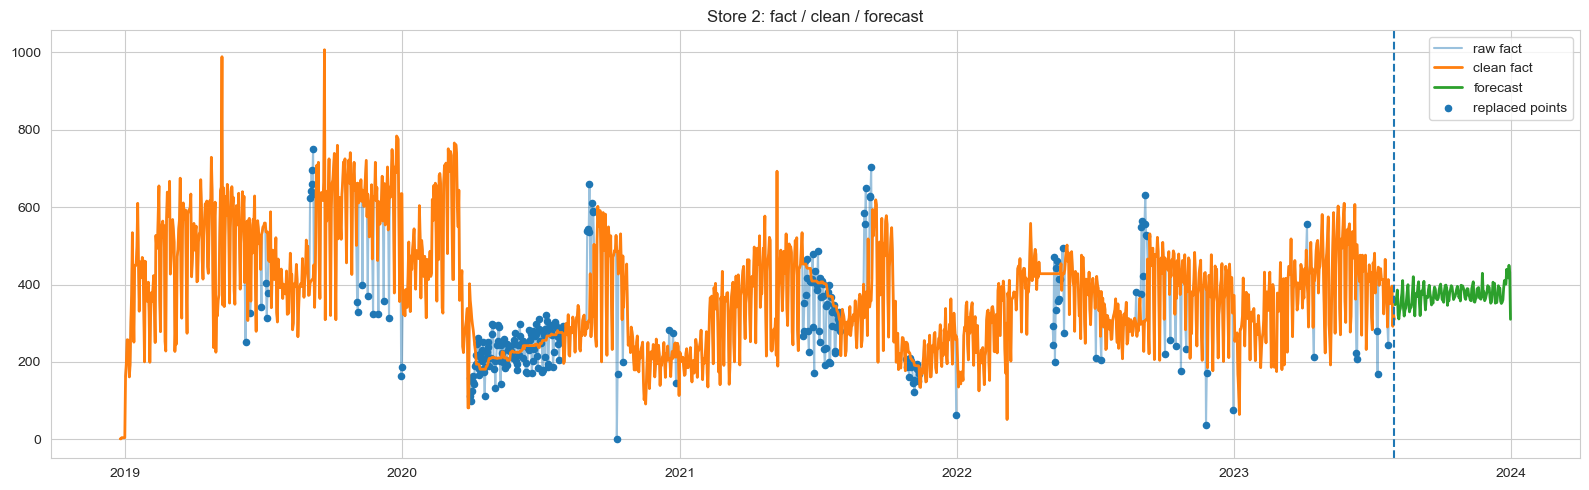

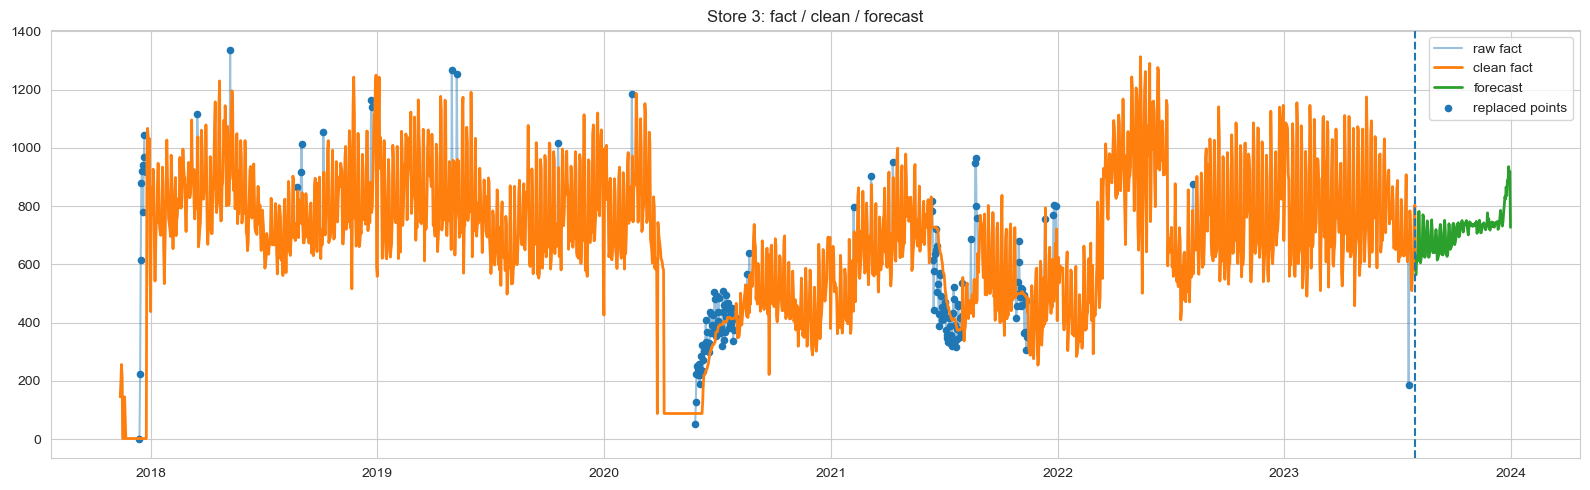

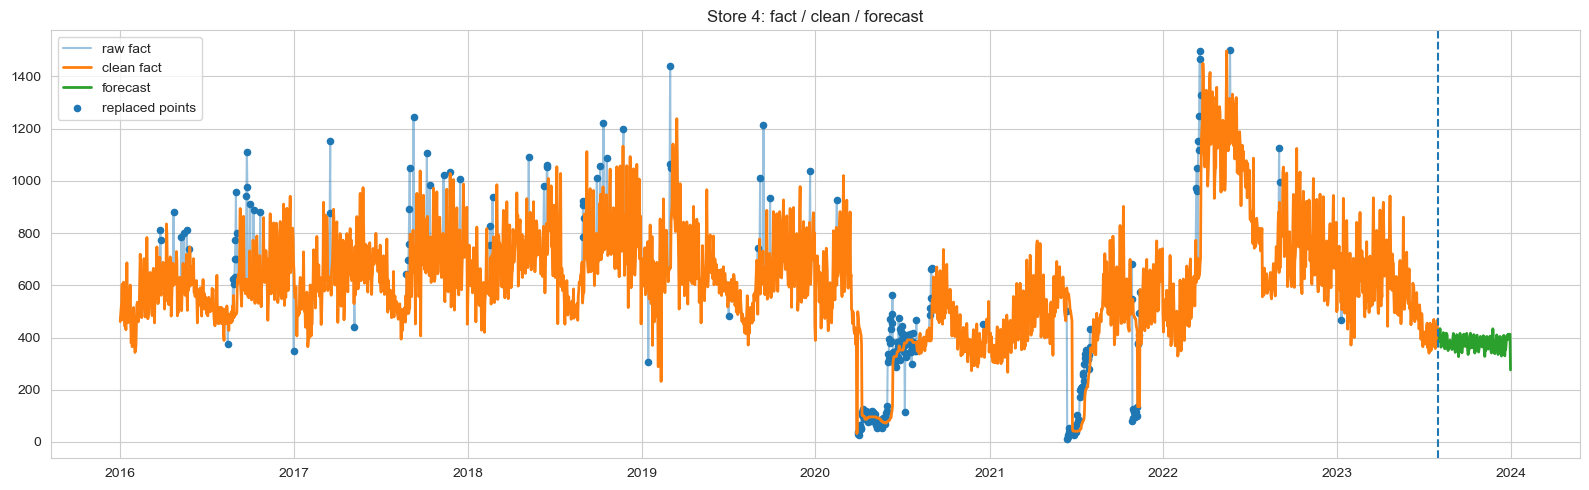

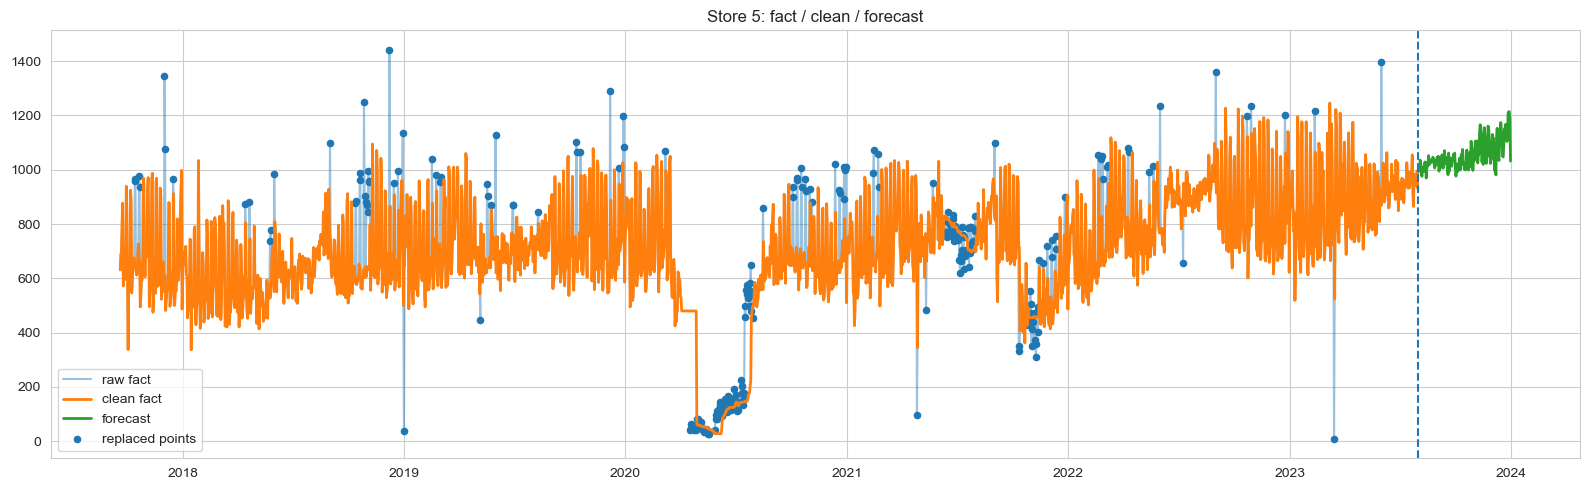

In [19]:


def plot_fact_clean_forecast(forecast_df: pd.DataFrame, store_id, train_end: pd.Timestamp):
    g = forecast_df[forecast_df["store_id"] == store_id].copy()

    plt.figure(figsize=(16, 5))

    plt.plot(
        g["DATE"],
        g["SALES_QUANTITY"],
        label="raw fact",
        alpha=0.45
    )

    plt.plot(
        g.loc[g["DATE"] <= train_end, "DATE"],
        g.loc[g["DATE"] <= train_end, "sales_clean"],
        label="clean fact",
        linewidth=2
    )

    plt.plot(
        g.loc[g["DATE"] > train_end, "DATE"],
        g.loc[g["DATE"] > train_end, "forecast"],
        label="forecast",
        linewidth=2
    )

    replaced = g[(g["DATE"] <= train_end) & (g["is_replaced"] == 1)]
    if len(replaced) > 0:
        plt.scatter(
            replaced["DATE"],
            replaced["SALES_QUANTITY"],
            s=20,
            label="replaced points"
        )

    plt.axvline(train_end, linestyle="--")
    plt.title(f"Store {store_id}: fact / clean / forecast")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


for store_id in sorted(forecast_df["store_id"].unique()):
    plot_fact_clean_forecast(forecast_df, store_id, TRAIN_END)